In [11]:
import tifffile as tiff
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("..")  # Ajouter le dossier parent au chemin
from core2.eva_losses import eva_acc, eva_dice, eva_miou, eva_sensitivity, eva_specificity

### Importer et visualiser l'image de segmentation (output du modèle)

Dimensions: (5636, 5638)
Nombre de bandes : 1
Projection : None
Min: 0, Max: 1, Moyenne: 0.11661540328466648
L'image contient uniquement des 0 et des 1.
Nombre de pixels par classe :
Classe 0: 28070224 pixels
Classe 1: 3705544 pixels
proportion de pixels de la classe 1 : 11.66%


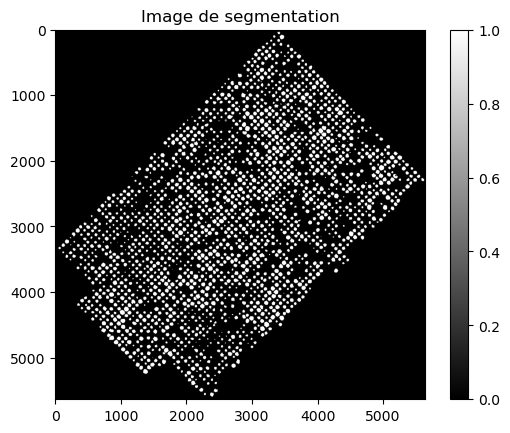

In [18]:
# Ouvrir image de segmentation (output du modèle)
with rasterio.open(r"C:\Git\données_pour_metric\Données_JRW45\10_epoch\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_only_region_to_segment_0_clean_seg.tif") as src:
    print(f"Dimensions: {src.shape}")  
    print(f"Nombre de bandes : {src.count}")
    print(f"Projection : {src.crs}")
    segmentation = src.read(1)

# Statistiques de l’image
print(f"Min: {segmentation.min()}, Max: {segmentation.max()}, Moyenne: {segmentation.mean()}")

# Vérifier qu'il y a seulement des 0 ou des 1 dans l'image
unique_values = np.unique(segmentation)
if np.array_equal(unique_values, [0, 1]):
    print("L'image contient uniquement des 0 et des 1.")
else:
    print(f"L'image contient d'autres valeurs : {unique_values}")

# Compter le nombre de pixels de chaque classe
unique, counts = np.unique(segmentation, return_counts=True)
print("Nombre de pixels par classe :")
for value, count in zip(unique, counts):
    print(f"Classe {value}: {count} pixels")

print(f"proportion de pixels de la classe 1 : {counts[1] / (counts[0] + counts[1]) * 100:.2f}%")

# Normaliser entre 0 et 255
#segmentation_normalized = (segmentation - segmentation.min()) / (segmentation.max() - segmentation.min()) * 255
#segmentation_normalized = segmentation_normalized.astype(np.uint8)

# Sauvegarder l'image normalisée
#with rasterio.open("C:/Git/données_pour_metric/données_pour_metric/fichier_avec_0_epoch/prediction_seg_2018_1km_6294_463_fixed.tif", "w", driver="GTiff",
#                   height=segmentation.shape[0], width=segmentation.shape[1],
#                   count=1, dtype=segmentation_normalized.dtype) as dst:
#    dst.write(segmentation_normalized, 1)


#visualiser l'image de segmentation
plt.imshow(segmentation, cmap="gray")
plt.colorbar()
plt.title("Image de segmentation")
plt.show()


## Importer l'image de ground truth (labels)



Dimensions: (5636, 5638)
Nombre de bandes : 1
Min: 0, Max: 1, Moyenne: 0.11756597039605778
L'image contient uniquement des 0 et des 1.
Nombre de pixels par classe :
Classe 0: 28040019 pixels
Classe 1: 3735749 pixels
proportion de pixels de la classe 1 : 11.76%


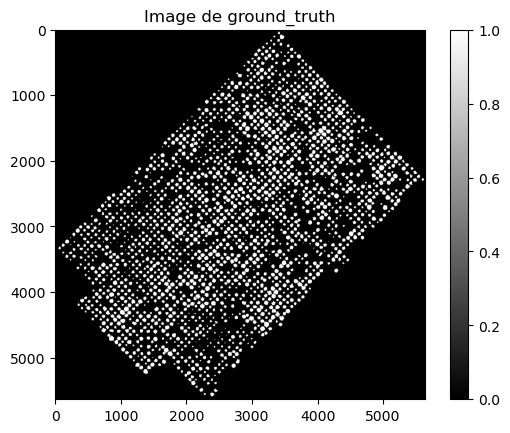

In [ ]:
# Ouvrir image de Ground Truth
with rasterio.open(r"C:\Git\données_pour_metric\Données_JRW45\10_epoch\Fdc_JR_W45_2023_03_21_panIMG_0037_6_MS_alP1_cor2-001_only_region_to_segment_0_clean_ground_truth.png") as src:
    print(f"Dimensions: {src.shape}")  
    print(f"Nombre de bandes : {src.count}")
    print(f"Projection : {src.crs}")
    ground_truth = src.read(1)

# Statistiques de l’image
print(f"Min: {ground_truth.min()}, Max: {ground_truth.max()}, Moyenne: {ground_truth.mean()}")

# Vérifier qu'il y a seulement des 0 ou des 1 dans l'image
unique_values = np.unique(ground_truth)
if np.array_equal(unique_values, [0, 1]):
    print("L'image contient uniquement des 0 et des 1.")
else:
    print(f"L'image contient d'autres valeurs : {unique_values}")

# Compter le nombre de pixels de chaque classe
unique, counts = np.unique(ground_truth, return_counts=True)
print("Nombre de pixels par classe :")
for value, count in zip(unique, counts):
    print(f"Classe {value}: {count} pixels")

print(f"proportion de pixels de la classe 1 : {counts[1] / (counts[0] + counts[1]) * 100:.2f}%")

# Normaliser entre 0 et 255
#ground_truth_normalized = (ground_truth - ground_truth.min()) / (ground_truth.max() - ground_truth.min()) * 255
#ground_truth_normalized = ground_truth_normalized.astype(np.uint8)

# Sauvegarder l'image normalisée
#with rasterio.open("C:/Git/données_pour_metric/données_pour_metric/fichier_avec_0_epoch/prediction_seg_2018_1km_6294_463_fixed.tif", "w", driver="GTiff",
#                   height=ground_truth.shape[0], width=ground_truth.shape[1],
#                   count=1, dtype=ground_truth_normalized.dtype) as dst:
#    dst.write(ground_truth_normalized, 1)


#visualiser l'image de labels
plt.imshow(ground_truth, cmap="gray")
plt.colorbar()
plt.title("Image de ground_truth")
plt.show()

## Calculer les métriques

In [9]:
from sklearn.metrics import accuracy_score

def eva_acc(y_true, y_label):
    
    return accuracy_score(y_true.flatten(), y_label.flatten())

eva_acc(ground_truth, segmentation)

0.9834359629010383

In [17]:
#Calculer les métriques eva_acc, eva_dice, eva_miou, eva_sensitivity, eva_specificity et mettre dans un tableau

eva_acc_value = eva_acc(ground_truth, segmentation)
eva_dice_value = eva_dice(ground_truth, segmentation)
# Calculer les métriques supplémentaires
eva_miou_value = eva_miou(ground_truth, segmentation)
eva_sensitivity_value = eva_sensitivity(ground_truth, segmentation)
eva_specificity_value = eva_specificity(ground_truth, segmentation)

# Calculer les TP, TN, FP, FN
TP = np.sum((ground_truth == 1) & (segmentation == 1))
TN = np.sum((ground_truth == 0) & (segmentation == 0))
FP = np.sum((ground_truth == 0) & (segmentation == 1))
FN = np.sum((ground_truth == 1) & (segmentation == 0))

# Créer un tableau avec les résultats
results_table = np.array([[eva_acc_value, eva_dice_value, eva_miou_value, eva_sensitivity_value, eva_specificity_value, TP, TN, FP, FN]])

#pandas dataframe avec les bons noms de colonnes
columns = ["Accuracy", "Dice", "IoU", "Sensitivity", "Specificity", "TP", "TN", "FP", "FN"]
df = pd.DataFrame(results_table, columns=columns)

print(df)







   Accuracy      Dice       IoU  Sensitivity  Specificity         TP  \
0  0.983436  0.929268  0.918732     0.925512     0.991153  3457479.0   

           TN        FP        FN  
0  27791954.0  248065.0  278270.0  
